In [1]:
import pandas as pd

In [4]:
iris = pd.read_csv('iris.csv')

In [18]:
iris.shape

(150, 5)

In [26]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<Axes: ylabel='Frequency'>

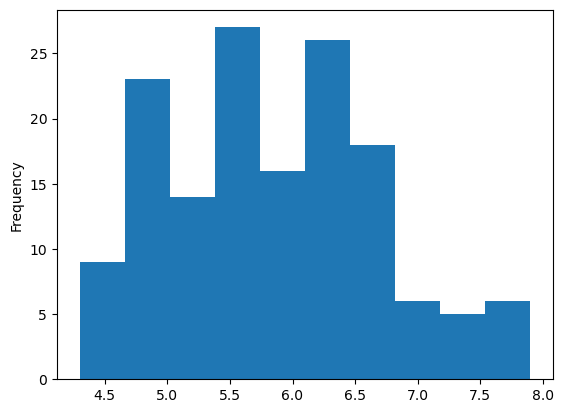

In [8]:
iris['sepal_length'].plot(kind='hist')

In [9]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [10]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

<Axes: xlabel='sepal_length', ylabel='species'>

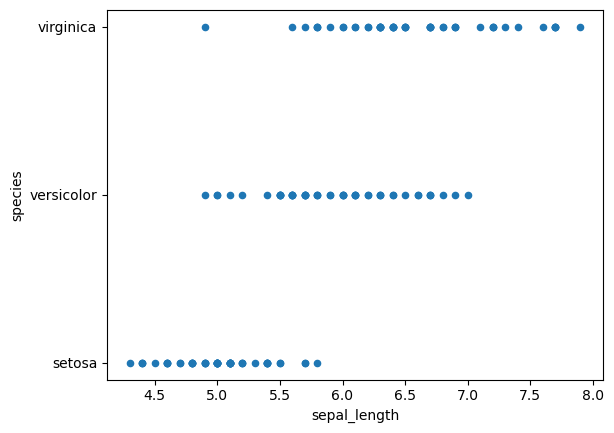

In [14]:
iris.plot(kind='scatter', x='sepal_length', y='species')

In [25]:
iris.pivot(columns='species', values='sepal_length')
# The output you see is more like one hot encoding. Each row has the value only for the column where it 'species' matches, and the rest are NaN.

species,setosa,versicolor,virginica
0,5.1,NaN,NaN
1,4.9,NaN,NaN
2,4.7,NaN,NaN
3,4.6,NaN,NaN
4,5.0,NaN,NaN
...,...,...,...
145,NaN,NaN,6.7
146,NaN,NaN,6.3
147,NaN,NaN,6.5
148,NaN,NaN,6.2


<Axes: >

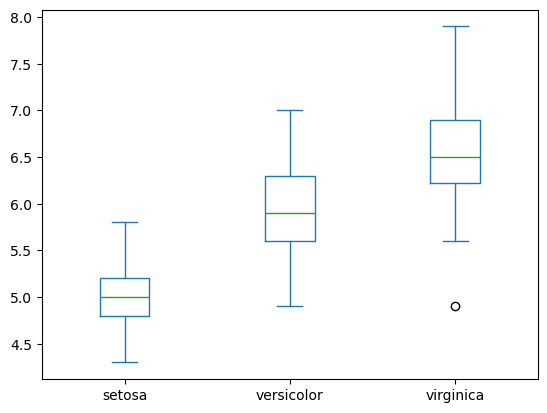

In [27]:
iris.pivot(columns='species', values='sepal_length').plot(kind='box')

<Axes: >

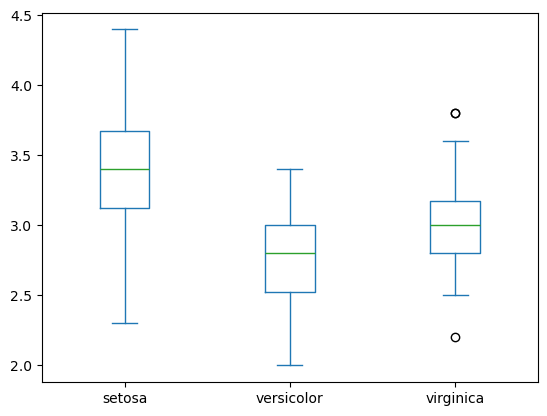

In [28]:
iris.pivot(columns='species', values='sepal_width').plot(kind='box')


<Axes: >

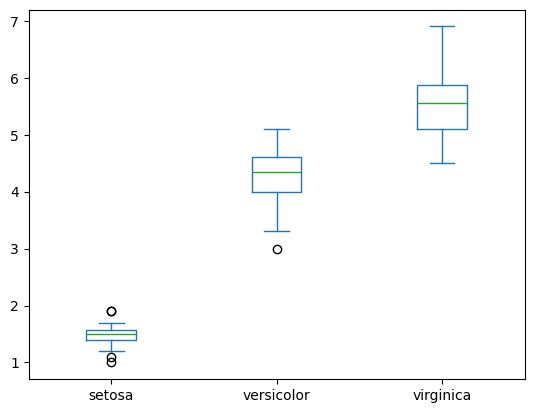

In [29]:
iris.pivot(columns='species', values='petal_length').plot(kind='box')


<Axes: >

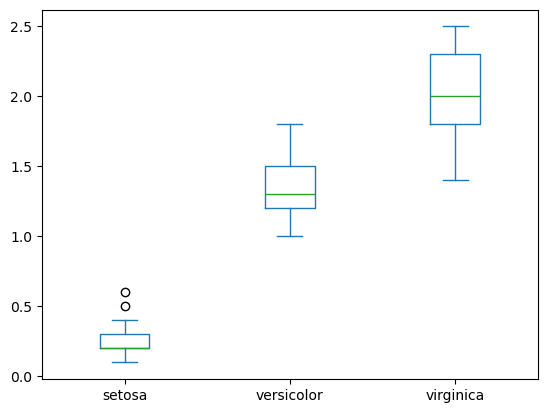

In [30]:
iris.pivot(columns='species', values='petal_width').plot(kind='box')


In [87]:
y = iris['species']
X = iris.drop(columns=['species'])


In [35]:
X[:5]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [38]:
X[:5]

,sepal_length,sepal_width,petal_length,petal_width
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


<Axes: ylabel='Frequency'>

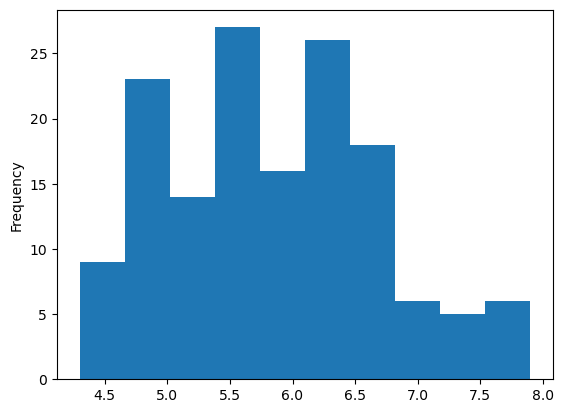

In [40]:
iris['sepal_length'].plot(kind='hist')

<Axes: ylabel='Frequency'>

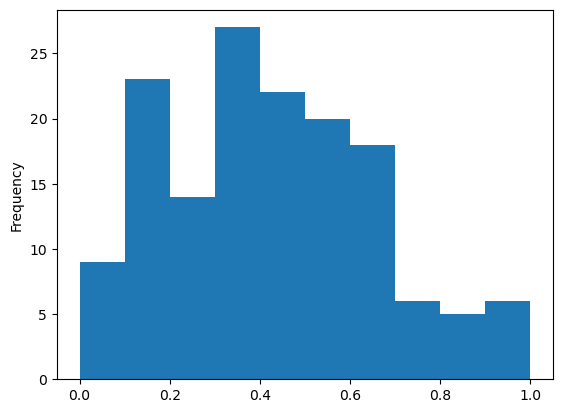

In [41]:
X['sepal_length'].plot(kind='hist')

<Axes: ylabel='count'>

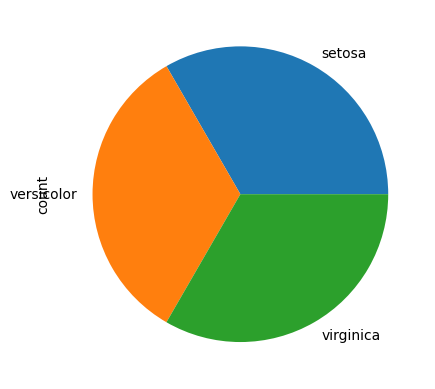

In [88]:
y.value_counts().plot(kind='pie')

In [90]:
y[0]

'setosa'

In [55]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [56]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [58]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [59]:
model.coef_

array([-0.40925151, -0.15500106,  1.49042508,  1.31853367])

In [60]:
model.intercept_

np.float64(-0.05219190919308003)

In [62]:
model.score(X_test, y_test)

0.9467245149351708

In [91]:
le.classes_

array([0, 1, 2])

In [74]:
iris.loc[73]

sepal_length           6.1
sepal_width            2.8
petal_length           4.7
petal_width            1.2
species         versicolor
Name: 73, dtype: object

In [80]:
X_test[:1]

,sepal_length,sepal_width,petal_length,petal_width
73,0.5,0.333333,0.627119,0.458333


In [86]:
le.inverse_transform([1])

array([1])

In [97]:
import numpy as np

np.array(X_test[:1])@model.coef_ + model.intercept_

array([1.2305166])

-0.20462575